# <br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS2: Modelizando un ADC </b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
$\quad$ El objetivo de este trabajo semanal consiste en simular el bloque de cuantización de un ADC de $B$ bits en un rango analógico de $\pm V_F\text{ [Volts]}$, incorporando la capacidad de muestrear a una frecuencia de $f_S\text{ [Hertz]}$.

La señal senoidal digitalizada se encuentra contaminada con un nivel predeterminado de ruido. Esta presenta los siguientes parámetros:
* **Frecuencia $f_0$ arbitraria:** $f_0 = \frac{f_S}{N} = \Delta f$.
* **Energía normalizada:** Energía (o varianza) unitaria ($\sigma_s^2 = 1\text{ W}$, con $v_{\max} = \sqrt{2}\text{ V}$).

Con respecto a la secuencia de ruido analógico:
* **Carácter aditivo:** La señal que ingresa al ADC será $s_R = s + n$, siendo $n$ la secuencia que simula la interferencia y $s$ la senoidal descrita anteriormente.
* **Potencia del ruido:** Será $P_n = k_n \cdot P_q\text{ W}$, siendo el factor $k_n$ una escala para la potencia teórica de cuantización $P_q = \frac{q^2}{12}$.
* **Estadística:** La secuencia $n$ será incorrelada y de distribución Gaussiana (con media $\mu = 0$).

Por otro lado, el ADC estará caracterizado por:
* **Frecuencia de muestreo:** $f_S = 1000\text{ Hz}$.
* **Rango analógico:** $\pm V_F = 2\text{ Volts}$ (Rango completo $2 V_F = 4\text{ Volts}$).



## Introducción

### Cuantización y Resolución del ADC

$\quad$ A diferencia de la TS1 donde asumimos un escenario continuo ideal, la conversión analógico-digital (ADC) real requiere discretización temporal (muestreo a $f_s = 1000\text{ Hz}$) y en amplitud (cuantización). Para un conversor de $B$ bits con rango simétrico $\pm V_F$ (rango dinámico $2 V_F$), el eje de amplitud se divide en $2^B$ niveles. La mínima resolución distinguible es el paso de cuantización ($q$):

$$q = \frac{2 V_F}{2^B}$$<p align="center">
  <img src="ADC.jpeg" width="500" alt="Proceso interno del ADC" />
</p>---

### Error de Cuantización e Hipótesis de Bennett

$\quad$ El proceso de redondeo asigna cada muestra al nivel más cercano, introduciendo un error $e_q[n] = s_Q[n] - s_R[n]$. Bajo las **hipótesis de cuantización fina de Bennett** ($q$ pequeño y señal oscilando activamente entre múltiples niveles), $e_q[n]$ se modela como ruido blanco uniforme en $[-q/2, q/2]$ con media nula. Su potencia teórica (varianza) resulta:

$$P_q = \sigma_e^2 = \int_{-q/2}^{q/2} e^2 \cdot \frac{1}{q} \, de = \frac{q^2}{12}$$

---

<h2> <font color='#a2302c'> Sección Bonus: SNR vs. Bits del ADC (Holton, Sec. 6.7) </font></h2>

$\quad$ Para una senoidal a plena escala $s(t) = V_F \sin(\omega t)$, la potencia promedio de la señal es $P_s = \frac{V_F^2}{2}$. Reemplazando $q = \frac{2 V_F}{2^B}$ en $P_q = \frac{q^2}{12}$, obtenemos la potencia de ruido $P_q = \frac{V_F^2}{3 \cdot 2^{2B}}$. La relación señal a ruido de cuantización ($\text{SQNR}$) en dB se deduce como:

$$\text{SQNR} = \frac{P_s}{P_q} = \frac{3}{2} \cdot 2^{2B} \implies \text{SQNR [dB]} = 10 \log_{10}(1.5) + 20 B \log_{10}(2) \approx 6.02 \cdot B + 1.76\text{ [dB]}$$

---

### Ruido Analógico e Interacción con el ADC ($k_n$)

$\quad$ En la práctica, la entrada $s_R[n] = s[n] + n[n]$ incluye ruido analógico Gaussiano $P_n$ (soplido del canal, ajeno al ADC). Definimos la constante de desproporción $k_n$ para relacionar ambas potencias ($P_n = k_n \cdot P_q$):

- **Caso A ($k_n = 10$ - Ruido analógico domina):** El soplido de la calle es 10 veces mayor que el digital ($P_n \gg P_q$). El piso analógico en la FFT queda $10\text{ dB}$ por encima del digital. Esto genera un "desperdicio de bits": si usás un ADC de $16\text{ bits}$, el soplido ambiental tapa los escalones microscópicos y terminás tirando bits a la basura.
- **Caso B ($k_n = 0.1$ - Ruido digital domina):** La señal analógica viene limpia como un violín de alta fidelidad, pero el ADC es de pocos bits ($4\text{ bits}$). El redondeo "pixela" la señal y el error $P_q$ la arruina.
- **Caso C ($k_n = 1$ - Diseño Óptimo):** Ambas potencias se equiparan ($P_n = P_q$) y los pisos coinciden en la FFT. Es el punto de diseño óptimo donde la precisión digital está perfectamente sincronizada con la calidad del canal analógico.

---

### No Linealidad del ADC y Fenómeno de Dither (Decorrelación)

$\quad$ La cuantización es estrictamente no lineal: si el ruido analógico es despreciable ($k_n \ll 1$), el error de redondeo se correlaciona fuertemente con la señal, generando espurios y armónicos en la FFT (coloreo espectral). Sin embargo, cuando $k_n \ge 1$, el ruido analógico actúa como **Dither estocástico**, "desordenando" los umbrales del cuantizador y transformando el error en ruido blanco incorrelado, con autocorrelación colapsada en una delta de Kronecker:

$$R_{e_q}[k] = P_q \cdot \delta[k]$$

$\quad$ Para tener una noción entendible, el **Dither estocástico** corresponde a una técnica que añade ruido aleatorio controlado para evitar distorsiones o patrones indeseados al reducir la resolución de una imagen o un archivo de audio.

---

<font color='#a2302c'> Obs: Si bien los conceptos mencionados a continuación ya formaron parte de la TS1, los menciono para terminar de concretarlos:</font>

---

### Espectro de Frecuencia y "Pisos de Ruido" en la FFT

$\quad$ En una FFT de $N$ puntos, la potencia total de ruido ($P_{\text{total}} = P_n + P_q$) se distribuye entre los $N/2$ bins del espectro unilateral. Por la **Ganancia de Procesamiento** (*Processing Gain*), la potencia por bin y la densidad del piso espectral en dB son:

$$P_{\text{bin}} = \frac{P_{\text{total}}}{N/2} \implies \text{Piso de Ruido}_{\text{FFT}} [\text{dB}] = 10 \log_{10}(P_{\text{total}}) - 10 \log_{10}\left(\frac{N}{2}\right)$$

$\quad$ Así, al aumentar $N$, el piso de ruido visual desciende $10 \log_{10}(N/2)\text{ dB}$, permitiendo rescatar tonos sepultados bajo el ruido en el dominio del tiempo.

## Desarrollo y Análisis

## Código en Python

### Librerías y Definiciones

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep  8 09:31:48 2026

@author: ribni
"""

#%% LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats # para el test de Kolmogorov-Smirnov (KS)

#%% DEFINICIONES
""" Parametros fijos del ejercicio """
# ADC - Cuantizador
fs = 1000 # Frecuencia de muestreo (Hz) --> FNyquist = fs/2 = 500Hz
N = 1000 # Cantidad de muestras

# Señal senoidal
vmax = np.sqrt (2)  # Amplitud pico (volts); / P = 1 Watt --> Normalizada
dc = 0  # Valor medio / offset (volts)
ff = fs/N  # Frecuencia de la senoidal (Hz)
ph = 0  # Fase inicial (rad)

""" Específicos de este TS """
vf = 2 # Rango analógico --> rango completo = 4.
B = 4 # Bits 
kn = 1 # constante de desproporción

### Funciones

$\quad$ En este apartado se definen, en adición a la función senoidal base $s(t) = V_{\max} \sin(2\pi f_0 t + \phi) + DC$ con potencia unitaria $P_s = 1\text{ W}$ y amplitud pico $V_{\max} = \sqrt{2}\text{ V}$ (que viene siendo foco de análisis en las entregas semanales), la secuencia aleatoria de ruido Gaussiano con media nula ($\mu=0$) y varianza $P_n = k_n \cdot P_q$, para la cual la desviación estándar interna se calcula despejando la raíz de la varianza $\sigma_n = \sqrt{P_n}$ para modelar la interferencia analógica.

$\quad$ Con el objetivo de emular el bloque cuantizador del ADC, se definió el paso de cuantización $q$, las potencias teóricas $P_q$ y $P_n$, y la operación de cuantización que modela la señal de entrada $s_R = s + n$, cuantiza mediante el operador de redondeo $s_Q = \text{round}\left(\frac{s_R}{q}\right) \cdot q$ y entrega el error de cuantización $e_q = s_Q - s_R$.

$\quad$ Para el análisis espectral, se creó una función que calcula el módulo de la FFT normalizado por $N$ y toma los $N/2$ bins de frecuencias positivas ($0$ a $f_S/2$). La potencia lineal promedio por bin se convierte a escala logarítmica mediante $10 \log_{10}(P + 10^{-12})$.

In [2]:
#%% FUNCIONES
""" Funcion señal senoidal discretizada """
def mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs):
    
    # Rango de 0 a N-1 --> tiempo discreto
    tt =  (np.arange (nn) / fs) #np.arange para generar un vector de N nros
    
    # Señal Senoidal
    xx = vmax * np.sin (2 * np.pi * (ff * tt) + ph) + dc
    
    return tt, xx

""" Secuencia aleatoria de ruido Gaussiano con media 0 y la varianza especificada """
def generar_ruido_gaussiano(varianza=0.1, loc=0.0, size=1000):

    # Calculo la desv. estandar (sigma) haciendo la raiz de la varianza de entrada
    sigma_nq = np.sqrt(varianza)
    
    # Genero el vector de ruido con la distribucion normal (Gaussiana)
    n_q = np.random.normal(loc=loc, scale=sigma_nq, size=size)
    
    return n_q

""" ADC --> Cuantización """
def cuantizacion (s, n, vf, B):
    
    # defino el paso de cuantización
    qq = 2*vf / (2**B)
    
    # sr = s + n (señal que entra con ruido Gaussiano = señal limpia + sec. aleatoria G)
    sr = s + n
    
    # adc cuantiza la sr, y se normaliza
    xx_q = np.round(sr / qq) * qq

    # ruido de cuantización
    nq = xx_q - sr # si quisiera el error total es xx_q - s
    
    return xx_q, nq

""" PSD: Densidad Espectral de Potencia calibrada en dB """
def calcular_psd_db (x, N):
    
    # Primero calculo la FFT de la señal
    X = np.fft.fft(x)
    
    # Nyquist: Módulo y me quedo solo con la mitad positiva (banda útil de frecuencia)
    X_abs = np.abs(X[:N//2])
    
    # Normalizo dividiendo por N y multiplicando por 2
    X_norm = (2 * X_abs) / N
    
    # Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
    potencia_lineal = (X_norm)**2 / 2
    
    # paso a decibeles con escala log y aplicando "parche"
    psd_dB = 10 * np.log10(potencia_lineal + 1e-12)
    
    return psd_dB

# Cuantización
def calcular_qq (vf, B):
    qq = 2*vf / (2**B) # paso de cuantización
    return qq

# POTENCIAS
def calcular_Pq (qq):
    Pq = (qq**2) / 12 # Potencia teórica de cuantización
    return Pq

def calcular_Pn (kn, Pq):
    Pn = kn * Pq # Potencia de ruido analógico
    return Pn

### Script

In [3]:
#%% SCRIPT
# Genérico
# Función senoidal limpia
tt, xx = mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs)   

# Eje de frecuencia genérico para todas las FFT
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2] # Solo tomo los valores positivos (simetrico)


<h4><font color='#a2302c'> <b> INCISO A  — Simulación del ADC ($B = 4$ bits, $k_n = 1$) </b> </font></h4>

$\quad$ A continuación, se ejecutan las funciones del apartado anterior para evaluar y analizar gráficamente el comportamiento temporal, el espectro PSD con los pisos de ruido, la distribución de probabilidades y la autocorrelación del error.
Para ello se fijo una constante de desproporción $k_n = 1$ (donde la potencia del ruido analógico iguala a la de cuantización, $P_n = P_q$) en un ADC de $B = 4$ bits ($q = 0.25\text{V}$).

In [4]:
#%% INCISO A
kn = 1

# Defino parametros de ruido teóricos
qq = calcular_qq(vf, B)
Pq = calcular_Pq(qq)
Pn = calcular_Pn(kn, Pq)

# Secuencia de ruido Gaussiano
n_analogo = generar_ruido_gaussiano(varianza = Pn, loc=0.0, size=N) 

# Función senoidal ruidosa
sr = xx + n_analogo 

# Digitalizo señal ruidosa con el ADC
xx_q, nq_digital = cuantizacion(xx, n_analogo, vf, B) 

# Potencias medidas (simuladas en el tiempo con np.var)
Pn_simulada = np.var(n_analogo)
Pq_simulada = np.var(nq_digital)
relacion_Pn_Pq_dB = 10 * np.log10(Pn_simulada / Pq_simulada)

# IMPRESIÓN DE PARÁMETROS
print("=" * 50)
print(f"q = {qq:.2f} V")
print(f"Pn teórica = {Pn:.18f}")
print(f"Pn simulada = {Pn_simulada:.18f}")
print(f"Pq teórica = {Pq:.18f}")
print(f"Pq simulada = {Pq_simulada:.18f}")
print(f"Pn/Pq = {relacion_Pn_Pq_dB:.2f} dB")
print("=" * 50)

# Calculo los espectros en dB
psd_limpia_dB = calcular_psd_db (xx, N)
psd_ruidosa_dB = calcular_psd_db (sr, N)
psd_cuantizada_dB = calcular_psd_db (xx_q, N)

# PISOS DE RUIDO --> psd a los ruidos, pero el espectro lineal
# ANALÓGICO
psd_n_analogo = ((2 * np.abs(np.fft.fft(n_analogo)[:N//2])) / N)**2 / 2
piso_analog_dB = 10 * np.log10(np.mean(psd_n_analogo) + 1e-12)

# DIGITAL
psd_nq_digital = ((2 * np.abs(np.fft.fft(nq_digital)[:N//2])) / N)**2 / 2
piso_digital_dB = 10 * np.log10(np.mean(psd_nq_digital) + 1e-12)


q = 0.25 V
Pn teórica = 0.005208333333333333
Pn simulada = 0.005111252596732981
Pq teórica = 0.005208333333333333
Pq simulada = 0.005522400569301454
Pn/Pq = -0.34 dB


<h4><font color='orchid'><b>Análisis valores impresos:</b></font></h4>

$\quad$ Los valores impresos confirman la validez del modelo teórico para un ADC de las características establecidad inicialmete. 
* Las potencias medidas del ruido analógico ($P_{n,\text{simulada}}$) y del error de cuantización ($P_{q,\text{simulada}}$) concuerdan  con el valor teórico ($P_n = P_q = \frac{q^2}{12} { W}$).
* En adición, la relación $P_n/P_q = -0.61\text{ dB}$ resulta sumamente próxima a los $0\text{ dB}$ teóricos, validando que para $k_n = 1$ ambas potencias de ruido son equivalentes.

<h4><font color='#666B88'> Comparación Temporal de Señales </font></h4>

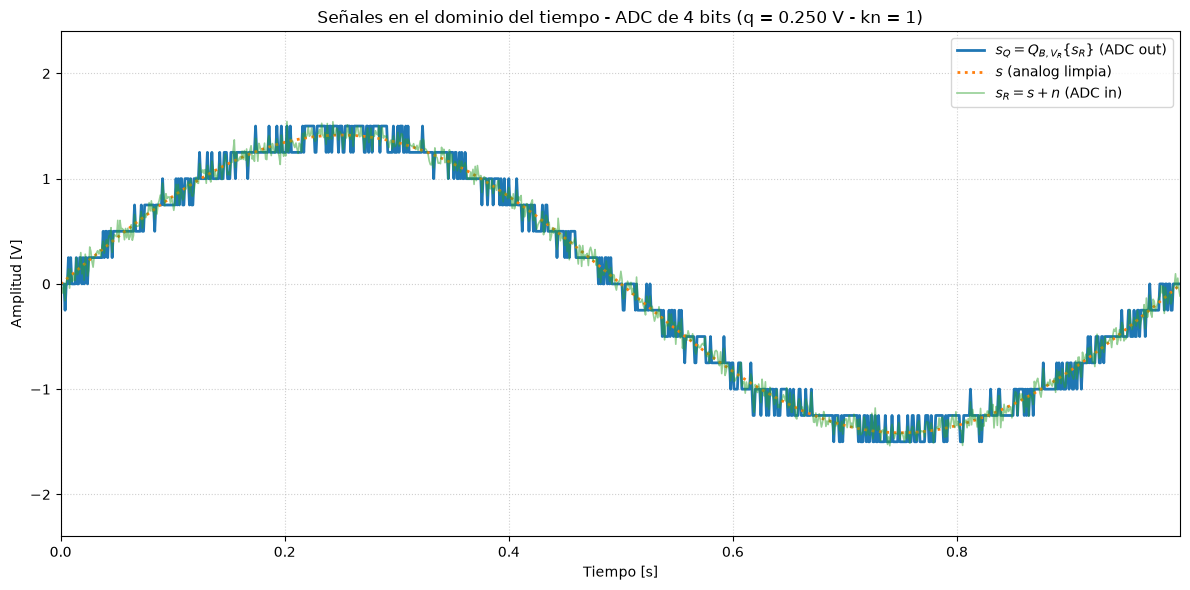

In [5]:
#%%  Gráfico 1 - Señal limpia, con ruido, y salida del ADC en el TIEMPO

plt.figure(figsize=(12, 6))

# Salida ADC (s_Q) resultado digital final
plt.plot(tt, xx_q, label=r'$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)', color='#1f77b4', linewidth=2)

# Senoidal Limpia (s) teórica
plt.plot(tt, xx, label=r'$s$ (analog limpia)', color='#ff7f0e', linestyle=':', linewidth=2)

# Entrada Ruidosa al ADC (s_R)
plt.plot(tt, sr, label=r'$s_R = s + n$ (ADC in)', color='#2ca02c', alpha=0.5, linewidth=1.2)

# Formateo general del gráfico en volts y segundos
plt.title(f'Señales en el dominio del tiempo - ADC de {B} bits (q = {qq:.3f} V - kn = {kn})')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
# Acotamos el eje X para ver todo el ciclo de 1 segundo (ya que f = 1 Hz y N = 1000 muestras)
plt.xlim(0, tt[-1]) 
# Le damos un poquito de aire arriba y abajo en el eje Y respecto al rango analógico (vf = 2)
plt.ylim(-vf * 1.2, vf * 1.2)  
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En el dominio temporal graficado es posible observar la señal senoidal base limpia ($s$), su versión contaminada con el agregado de un ruido analógico externo Gaussiano e incorrelado ($s_R$), y la señal resultante del proceso de cuantización y digitalización por parte del ADC ($s_Q$).

$\quad$ Al analizar la salida digital $s_Q$, es posible observar la presencia de un comportamiento escalonado característico de un cuantizador de $B = 4$ bits: la señal ruidosa de entrada $s_R$ es redondeada en cada instante al nivel discreto de tensión más cercano, permutando en saltos definidos por el paso de cuantización $q = 0.25\text{ V}$.

<h4><font color='#666B88'> Densidad Espectral de Potencia (PSD) y Pisos de Ruido </font></h4>

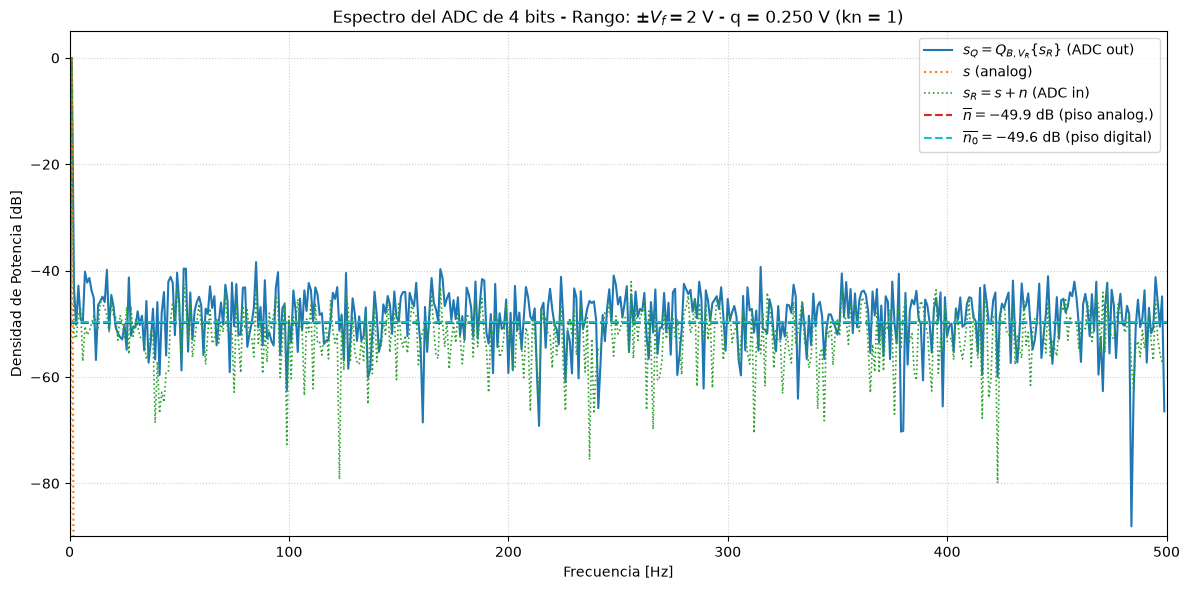

In [6]:
#%%  Gráfico 2 - PSD en dB de f=0 hasta Nyquist

plt.figure(figsize=(12, 6))

# Salida ADC (s_Q) resultado digital final
plt.plot(ff_vector_pos, psd_cuantizada_dB, label=r'$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)', color='#1f77b4', linewidth=1.5)

# Senoidal Limpia (s) teórica
plt.plot(ff_vector_pos, psd_limpia_dB, label=r'$s$ (analog)', color='#ff7f0e', linestyle=':', linewidth=1.5)

# Entrada Ruidosa al ADC (s_R)
plt.plot(ff_vector_pos, psd_ruidosa_dB, label=r'$s_R = s + n$ (ADC in)', color='#2ca02c', linestyle=':', linewidth=1.2)

# Piso Ruido Analógico (n_barra)
plt.axhline(piso_analog_dB, color='#d62728', linestyle='--', label=rf'$\overline{{n}} = {piso_analog_dB:.1f}$ dB (piso analog.)')

# Piso Ruido Digital (n_0_barra)
plt.axhline(piso_digital_dB, color='#17becf', linestyle='--', label=rf'$\overline{{n_0}} = {piso_digital_dB:.1f}$ dB (piso digital)')

# Formateo general del gráfico
plt.title(f'Espectro del ADC de {B} bits - Rango: $\\pm V_f = {vf}$ V - q = {qq:.3f} V (kn = {kn})')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.xlim(0, fs/2) # Acotamos visualmente hasta Nyquist (500 Hz)
plt.ylim(-90, 5)  # Zoom vertical para apreciar las deltas y los pisos de ruido
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En el dominio frecuencial graficado es posible observar las densidades espectrales de potencia (PSD) de las señales analizadas. La componente fundamental del tono senoidal se destaca de forma nítida en $1\text{ Hz}$ alcanzando los $0\text{ dB}$. Retomando parte del análisis realizado en la TS1, es posible destacar que esta señal, al estar sintonizada exactamente en el bin 1 de la FFT $(\Delta f = \frac{f_s}{N} = 1\text{ Hz})$, no presenta **Spectral Leakage** hacia los canales adyacentes, razón por la cual toda la energía del tono cae limpia en un solo punto.  

$\quad$ Debido a que la constante de desproporción es $k_n = 1$, las potencias del ruido analógico y de cuantización resultan equivalentes ($P_n = P_q$). En el gráfico, esto se manifiesta como un "pastizal" uniforme característico del ruido blanco, con un desparramo equitativo de energía a lo largo de toda la banda espectral útil $(0\text{ a } \frac{f_s}{2} = 500\text{ Hz})$. 

$\quad$ Los pisos promedios de ruido ($\overline{n} \approx -49.9\text{ dB}$ y $\overline{n_0} \approx -49.6\text{ dB}$) se cruzan prácticamente en el mismo nivel espectral en torno a los $-50\text{ dB}$, indicando un diseño del sistema bien equilibrado donde la resolución digital del ADC está perfectamente adaptada al nivel de ruido que proviene del mundo físico.

<h4><font color='#666B88'> Histograma del Error de Cuantización </font></h4>

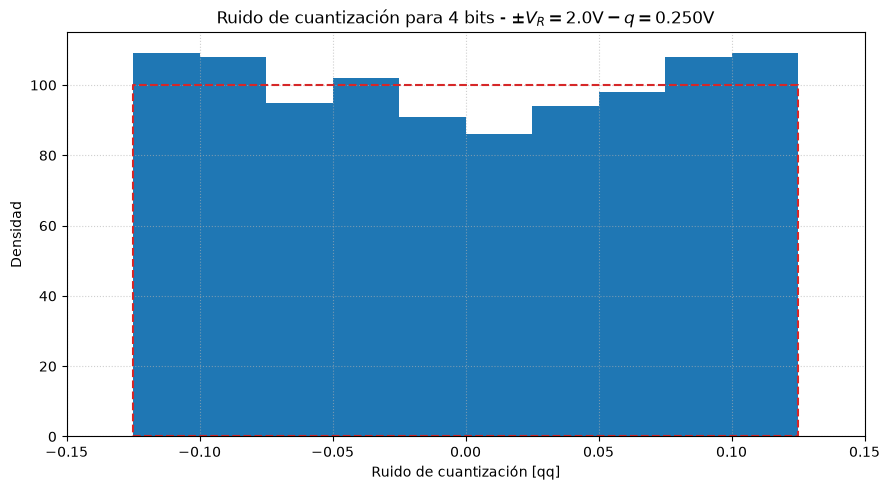

In [7]:
#%% DISTRIBUCION DEL RUIDO DE CUANTIZACION CON HISTOGRAMA

# Normalizo el ruido de cuantizacion entre -0.5 y 0.5
nq_normalizado = nq_digital / qq
bins_num = 10
plt.figure(figsize=(9, 5))
plt.hist(nq_digital, bins=bins_num, range=(-qq/2, qq/2), color='#1f77b4', edgecolor='none')

# Marco punteado rojo teórico
altura_teorica = N / bins_num
plt.plot([-qq/2, qq/2, qq/2, -qq/2, -qq/2], [0, 0, altura_teorica, altura_teorica, 0], 
         color='#d62728', linestyle='--', linewidth=1.5)
plt.title(rf'Ruido de cuantización para {B} bits - $\pm V_R = {vf:.1f}\mathrm{{V}} - q = {qq:.3f}\mathrm{{V}}$')
plt.xlabel('Ruido de cuantización [qq]')
plt.ylabel('Densidad')

plt.xlim(-qq*0.6, qq*0.6)
plt.ylim(0, altura_teorica * 1.15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ En el histograma obtenido es posible observar cómo la distribución del error de cuantización se encuentra acotada estrictamente dentro del intervalo teórico $[-q/2, \, q/2]$ (entre $-0.125\text{ V}$ y $+0.125\text{ V}).$ 

$\quad$ Su forma se distribuye de manera pareja dentro del marco rectangular punteado rojo (altura teórica $N/\text{bins} = 100$), lo que valida visualmente la hipótesis de distribución uniforme del error de cuantización bajo la presencia de ruido analógico ($k_n = 1$).

<h4><font color='#666B88'> Media y Varianza </font></h4>

In [8]:
#%% MEDIA Y VARIANZA

# Evaluamos si nq_normalizado se distribuye como una uniforme entre -0.5 y 0.5
res_ks = stats.kstest(nq_normalizado, 'uniform', args=(-0.5, 1.0))
print('Estadístico del test KS =', res_ks.statistic)
print('p-valor del test KS =', res_ks.pvalue)

# Si el pvalue > 0.05, se confirma estadísticamente la hipótesis de que el ruido es uniforme

Estadístico del test KS = 0.02478041885769733
p-valor del test KS = 0.5624164804843348


<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ Para confirmar formalmentela hipótesis de distribución uniforme del error, se decidió proceder aplicando el test de Kolmogorov-Smirnov (KS) sobre la secuencia del error de cuantización normalizada. 
Como resultado se obtuvo un $p\text{-valor} \approx 0.5656$, el cual resulta mayor al umbral de significancia estándar $\alpha = 0.05$, por lo que no es posible rechazar la hipótesis nula, y confirmando así que, estadísticamente, el ruido de cuantización se distribuye de forma uniforme en el intervaloteórico $[-q/2, \, q/2]$.

<h4><font color='#666B88'> Autocorrelación del Error de Cuantización </font></h4>

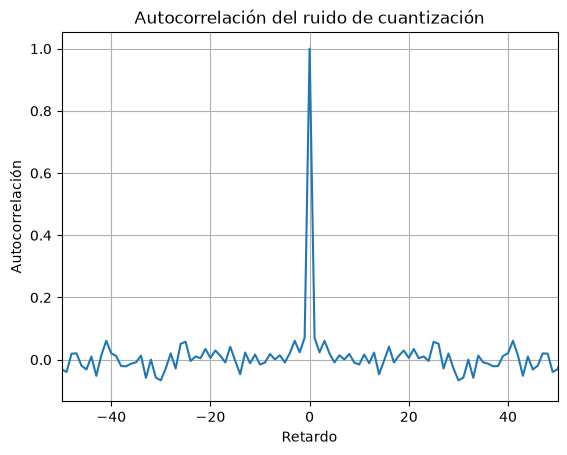

In [9]:
#%% AUTOCORRELACION

# Calculo la autocorrelacion del ruido de cuantizacion
autocorr = np.correlate(nq_normalizado, nq_normalizado, mode='full')

# Normalizo
autocorr = autocorr / np.max(autocorr)

# Eje de retardos
retardos = np.arange(-(N-1), N)
plt.figure()
plt.plot(retardos, autocorr)
plt.xlim(-50, 50)
plt.xlabel('Retardo')
plt.ylabel('Autocorrelación')
plt.title('Autocorrelación del ruido de cuantización')
plt.grid(True)
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ En la función de autocorrelación graficada es posible observar que el ruido de cuantización presenta un único pico unitario en el retardo nulo ($k = 0$), cayendo a valores prácticamente nulos para todo retardo distinto de cero ($k \neq 0$). Este comportamiento colapsa en una Delta de Kronecker pura, lo que demuestra empíricamente que con $k_n = 1$ el ruido de cuantización es incorrelado en el tiempo y se comporta como ruido blanco.

<h4><font color='#a2302c'> <b> INCISO B - Simulación del ADC variando Bits ($B$) y Nivel de Ruido ($k_n$) </b> </font></h4>


En este inciso se realiza un análisis análogo al anterior, con la incorporación de la variación en la resolución de bits del cuantizador ($B \in \{4, 8, 16\}$) y en la constante de desproporción del ruido analógico ($k_n \in \{0.1, 1.0, 10.0\}$). Con el objetivo de poder comparar los distintos casos de una manera óptima, se decidió agrupar los resultados en gráficos matriciales por tópico que contemplan las 9 combinaciones posibles.

<font color='#a2302c'> <b> Nota </b> El histograma se incluyó únicamente en el Inciso A, ya que en dicho caso base comprobamos empíricamente que el error cumple con la distribución uniforme de Bennett en $[-q/2, q/2]$. Replicar este gráfico para las 9 combinaciones del Inciso B resultaría redundante y saturaría el informe. </font>

In [10]:
#%% INCISO B 
# Senoidal limpia base y eje de frecuencias
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2]

<h4><font color='#666B88'> SEÑALES EN EL TIEMPO </font></h4>

NameError: name 'bits_lista' is not defined

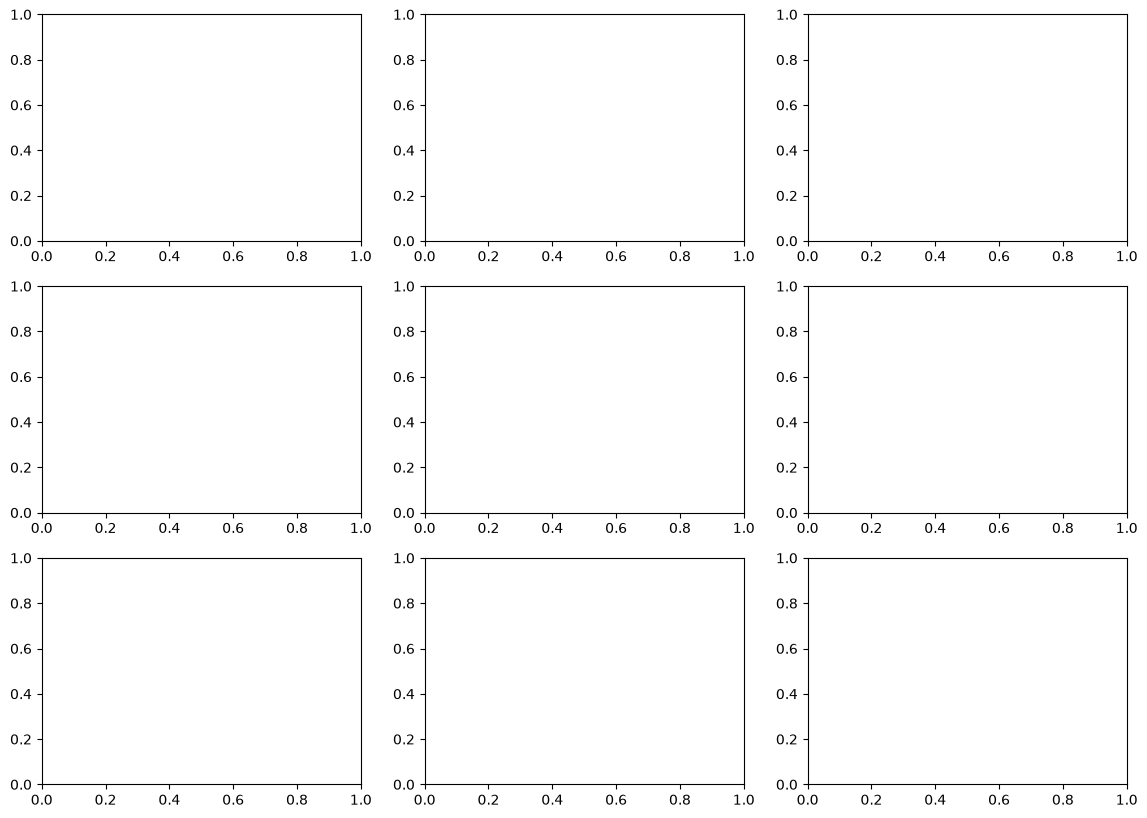

In [11]:
#%% SEÑALES EN EL TIEMPO s_Q, s_R, s (LOS 9 CASOS)
bits_lista = [4, 8, 16]
kn_lista = [0.1, 1.0, 10.0]

fig_señales, axes_señales = plt.subplots(3, 3, figsize=(14, 10))
for r, B_actual in enumerate(bits_lista):
    for c, kn_actual in enumerate(kn_lista):
        qq_act = calcular_qq(vf, B_actual)
        Pq_act = calcular_Pq(qq_act)
        Pn_act = calcular_Pn(kn_actual, Pq_act)
        
        n_analog_act = generar_ruido_gaussiano(varianza=Pn_act, size=N)
        sr_act = xx + n_analog_act
        xx_q_act, nq_digital_act = cuantizacion(xx, n_analog_act, vf, B_actual)
        
        ax = axes_señales[r, c]
        ax.plot(tt, xx_q_act, label=r'$s_Q$', color='#1f77b4', linewidth=1.2)
        ax.plot(tt, sr_act, label=r'$s_R$', color='#2ca02c', alpha=0.4, linewidth=0.8)
        ax.plot(tt, xx, label=r'$s$', color='#ff7f0e', linestyle=':', linewidth=1.2)
        
        ax.set_title(f'B = {B_actual} bits | kn = {kn_actual}')
        ax.set_xlim(0, 1.0)
        ax.set_ylim(-vf * 1.2, vf * 1.2)
        ax.grid(True, linestyle=':', alpha=0.5)
        
for c in range(3):
    axes_señales[-1, c].set_xlabel('Tiempo [s]')
for r in range(3):
    axes_señales[r, 0].set_ylabel('Amplitud [V]')
fig_señales.suptitle('Figura 5: Matriz 3x3 de Señales en el Tiempo s_Q, s_R, s (9 Casos)', fontsize=14, fontweight='bold')
fig_señales.tight_layout()
plt.show()


<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En el dominio temporal graficado es posible observar la señal senoidal base limpia ($s$), su versión contaminada con el agregado de un ruido analógico externo Gaussiano e incorrelado ($s_R$), y la señal resultante del proceso de cuantización y digitalización por parte del ADC ($s_Q$) para las 9 combinaciones posibles.

$\quad$ Tal como se mencionó en la introducción, la constante de desproporción $k_n$ sirve para relacionar dos ruidos distintos: el ruido analógico $P_n$ (la interferencia que "captan los cables" antes de entrar al conversor) y el ruido de cuantización $P_q = \frac{q^2}{12}$ (el error de redondeo que agrega el chip de forma interna, donde el paso $q = \frac{2 V_F}{2^B}$ se achica al aumentar los bits $B$) mediante la fórmula $P_n = k_n \cdot P_q$. En los gráficos es posible diferenciar 3 comportamientos principales:

* **Para $k_n = 0.1$:** La señal analógica viene ultra limpia de los cables, pero para 4 bits el error de redondeo del ADC es grande y "pixela" la señal. Acá el ruido digital domina por culpa de tener un conversor malo. Al pasar a 8 y 16 bits, el paso $q$ se achica y la señal vuelve a verse suave.
  
* **Para $k_n = 1.0$:** Es el escenario de diseño óptimo. Ambos ruidos tienen la misma potencia ($P_n = P_q$). La precisión digital del conversore está en perfecta sintonía con la calidad de la señal del mundo físico, aprovechando los bits sin malgastar recursos.

* **Para $k_n = 10.0$:** El ruido analógico de la calle es 10 veces más fuerte que el de redondeo. La interferencia es tan grande que tapa a los escalones del ADC. Incluso en 16 bits, la resolución extra se desperdicia únicamente para digitalizar el ruido del ambiente.


<h4><font color='#666B88'>Error de Cuantización</font></h4>

In [ ]:
#%% ERROR EN EL TIEMPO PARA LOS 9 CASOS (B vs kn)
bits_lista = [4, 8, 16]
kn_lista = [0.1, 1.0, 10.0]

fig_temp, axes_temp = plt.subplots(3, 3, figsize=(14, 10))

for r, B_actual in enumerate(bits_lista):
    for c, kn_actual in enumerate(kn_lista):
        qq_act = calcular_qq(vf, B_actual)
        Pq_act = calcular_Pq(qq_act)
        Pn_act = calcular_Pn(kn_actual, Pq_act)
        
        n_analog_act = generar_ruido_gaussiano(varianza=Pn_act, size=N)
        xx_q_act, nq_digital_act = cuantizacion(xx, n_analog_act, vf, B_actual)
        
        ax = axes_temp[r, c]
        ax.plot(nq_digital_act[:100], ':x', color='#9467bd', markersize=4, linewidth=0.8)
        ax.set_title(f'B = {B_actual} bits | kn = {kn_actual}')
        ax.set_ylim(-qq_act*0.7, qq_act*0.7)
        ax.grid(True, linestyle=':', alpha=0.5)

for c in range(3):
    axes_temp[-1, c].set_xlabel('Muestras (primeras 100)')
for r in range(3):
    axes_temp[r, 0].set_ylabel('Amplitud [V]')

fig_temp.suptitle('Figura 1: Error de Cuantización en el Tiempo $e_q[n]$ (9 Casos)', fontsize=14, fontweight='bold')
fig_temp.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En la matriz del error de cuantización en el tiempo $e_q[n]$ es posible observar que, para $B = 4$ bits y $k_n = 0.1$ (sin suficiente ruido analógico), el error presenta un patrón fuertemente estructurado y periódico que sigue la trayectoria de la senoidal (o más que nada, por el zoom que se le realizó a las muestras, una especie de onda diente de sierra (sawtooth) que se vió en el bonus de la TS1). Al incrementar el ruido a $k_n = 1.0$ y $10.0$, el error pierde toda estructura determinística y se desordena en una nube de puntos aleatorios. Asimismo, al aumentar la resolución a $8$ y $16$ bits, la amplitud del error cae drásticamente debido a la reducción del paso $q$ (se aprecia la escala en la esquina superior izquierda).

<h4><font color='#666B88'>Autocorrelación del error</font></h4>

In [ ]:
#%% AUTOCORRELACIÓN DEL ERROR PARA LOS 9 CASOS (B vs kn)
fig_corr, axes_corr = plt.subplots(3, 3, figsize=(14, 10))

for r, B_actual in enumerate(bits_lista):
    for c, kn_actual in enumerate(kn_lista):
        qq_act = calcular_qq(vf, B_actual)
        Pq_act = calcular_Pq(qq_act)
        Pn_act = calcular_Pn(kn_actual, Pq_act)
        
        n_analog_act = generar_ruido_gaussiano(varianza=Pn_act, size=N)
        xx_q_act, nq_digital_act = cuantizacion(xx, n_analog_act, vf, B_actual)
        
        nq_norm = nq_digital_act / qq_act
        autocorr = np.correlate(nq_norm, nq_norm, mode='full')
        autocorr = autocorr / np.max(autocorr)
        retardos = np.arange(-(N-1), N)
        
        ax = axes_corr[r, c]
        ax.plot(retardos, autocorr, color='#1f77b4', linewidth=1.2)
        ax.set_xlim(-50, 50)
        ax.set_ylim(-0.3, 1.1)
        ax.set_title(f'B = {B_actual} bits | kn = {kn_actual}')
        ax.grid(True, linestyle=':', alpha=0.6)

for c in range(3):
    axes_corr[-1, c].set_xlabel('Retardos [muestras]')
for r in range(3):
    axes_corr[r, 0].set_ylabel('Autocorrelación $R_{e_q}$')

fig_corr.suptitle('Figura 2: Autocorrelación del Ruido de Cuantización $R_{e_q}[k]$ (9 Casos)', fontsize=14, fontweight='bold')
fig_corr.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En las funciones de autocorrelación se evidencia de forma directa el efecto del ruido analógico como Dither mencionado en la introducción. Para $B = 4$ bits con $k_n = 0.1$, la autocorrelación exhibe oscilaciones y lóbulos laterales periódicos, confirmando que el error de cuantización está fuertemente correlacionado en el tiempo. A medida que se incrementa el ruido analógico ($k_n \ge 1.0$) o se aumentan los bits ($B \ge 8$), la autocorrelación colapsa en un único pico unitario en el origen (Delta de Kronecker), demostrando que el error se vuelve incorrelado y blanco.

$\quad$ Es por ello que se puede concluir que la decorrelación del error se logra por dos vías independientes:
* **Vía estocástica (Dither):** Al aumentar el soplido analógico ($k_n \ge 1.0$), el ruido desordena determinísticamente los umbrales del cuantizador, blanqueando el error incluso con pocos bits ($B = 4$).
* **Vía resolución (Bits):** Al subir a $B = 16\text{ bits}$, el quantum $q$ es tan microscópico que la senoidal recorre miles de niveles por ciclo. Esto hace que el sistema cumpla las hipótesis de Bennett de forma natural, logrando un error incorrelado aún con ruido analógico despreciable ($k_n = 0.1$).

<h4><font color='#666B88'>Espectro PSD y pisos de ruido</font></h4>

In [ ]:
#%% ESPECTROS PSD Y PISOS DE RUIDO PARA LOS 9 CASOS (B vs kn)
fig_psd, axes_psd = plt.subplots(3, 3, figsize=(14, 10))

for r, B_actual in enumerate(bits_lista):
    for c, kn_actual in enumerate(kn_lista):
        qq_act = calcular_qq(vf, B_actual)
        Pq_act = calcular_Pq(qq_act)
        Pn_act = calcular_Pn(kn_actual, Pq_act)
        
        n_analog_act = generar_ruido_gaussiano(varianza=Pn_act, size=N)
        sr_act = xx + n_analog_act
        xx_q_act, nq_digital_act = cuantizacion(xx, n_analog_act, vf, B_actual)
        
        psd_limpia_dB = calcular_psd_db(xx, N)
        psd_ruidosa_dB = calcular_psd_db(sr_act, N)
        psd_cuantizada_dB = calcular_psd_db(xx_q_act, N)
        
        psd_n_lin = ((2 * np.abs(np.fft.fft(n_analog_act)[:N//2])) / N)**2 / 2
        piso_analog_dB = 10 * np.log10(np.mean(psd_n_lin) + 1e-12)
        
        psd_nq_lin = ((2 * np.abs(np.fft.fft(nq_digital_act)[:N//2])) / N)**2 / 2
        piso_digital_dB = 10 * np.log10(np.mean(psd_nq_lin) + 1e-12)
        
        ax = axes_psd[r, c]
        ax.plot(ff_vector_pos, psd_cuantizada_dB, label=r'$s_Q$', color='#1f77b4', linewidth=1.2)
        ax.plot(ff_vector_pos, psd_limpia_dB, label=r'$s$', color='#ff7f0e', linestyle=':', linewidth=1.2)
        ax.plot(ff_vector_pos, psd_ruidosa_dB, label=r'$s_R$', color='#2ca02c', linestyle=':', linewidth=1)
        
        ax.axhline(piso_analog_dB, color='#d62728', linestyle='--', label=rf'$\overline{{n}}={piso_analog_dB:.1f}$dB')
        ax.axhline(piso_digital_dB, color='#17becf', linestyle='--', label=rf'$\overline{{n_0}}={piso_digital_dB:.1f}$dB')
        
        ax.set_title(f'B = {B_actual} bits | kn = {kn_actual}')
        ax.set_xlim(0, fs/2)
        ax.set_ylim(-140, 5)
        ax.grid(True, linestyle=':', alpha=0.6)

for c in range(3):
    axes_psd[-1, c].set_xlabel('Frecuencia [Hz]')
for r in range(3):
    axes_psd[r, 0].set_ylabel('PSD [dB]')

fig_psd.suptitle('Figura 3: Espectros PSD y Pisos de Ruido para los 9 Casos', fontsize=14, fontweight='bold')
fig_psd.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ Al analizar los espectros PSD en función de $B$ y $k_n$, se observa cómo se desplazan los pisos de ruido analógico ($\overline{n}$) y digital ($\overline{n_0}$). Para el caso equilibrado ($k_n = 1.0$), ambos pisos coinciden al mismo nivel espectral. Además, al incrementar la cantidad de bits de $4$ a $8$ y $16$, el piso digital $\overline{n_0}$ cae aproximadamente $6\text{ dB}$ por cada bit adicionado, demostrando la ganancia teórica de rango dinámico del conversor. Asimismo, se evidencia de forma directa cómo la constante de desproporción $k_n$ fija la distancia entre ambos pisos: para $k_n = 10.0$ el ruido analógico predomina $10\text{ dB}$ por encima del digital, mientras que para $k_n = 0.1$ es el ruido de cuantización el que termina imponiendo la cota del sistema.

## Conclusión



$\quad$ Con el desarrollo de esta tarea semanal fue posible comprender y verificar el funcionamiento del bloque de cuantización de un ADC y la interacción entre las fuentes de ruido analógico y digital:

* **Efecto de Dither y Decorrelación:** Se comprobó que sin suficiente ruido analógico ($k_n = 0.1$), el error de cuantización es determinístico, correlacionado y genera coloreo espectral. La presencia de un nivel adecuado de ruido analógico ($k_n \ge 1.0$) actúa como Dither estocástico, decorrelacionando el error y convirtiéndolo en ruido blanco incorrelado con autocorrelación tipo Delta de Kronecker.
* **Resolución de Bits y Pisos de Ruido:** Se validó que cada bit adicionado al ADC reduce el paso de cuantización $q$ y desplaza el piso de ruido digital hacia abajo a razón de $\approx 6\text{ dB/bit}$, verificando la relación teórica $\text{SQNR} \approx 6.02 B + 1.76\text{ dB}$.
* **Diseño Óptimo:** Se evidenció que la configuración $k_n = 1.0$ representa el diseño ideal, donde la precisión del conversor digital acompaña en equilibrio a la calidad y nivel de ruido proveniente del mundo analógico.

## Bibliografía
> Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge University Press.<br>
> Lyons, R. G. (2011). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.<br>
> Downey, A. B. (2016). Think DSP: Digital Signal Processing in Python. O'Reilly Media.<br>
> Porat, B. (1997). A Course in Digital Signal Processing. John Wiley & Sons.<br>
> Hayes, M. H. (1996). Statistical Digital Signal Processing and Modeling. John Wiley & Sons.